# ДЗ №1 СУНЦ МГУ - Numpy practice

**Среда:** Python 3.14.7. Локальные модули `functions.py` и `functions_vectorized.py` повторно импортируются при каждом запуске ячейки с решением.


### Туториальные задачи
__(9 баллов)__

Ниже приведены задачи на работу с numpy-массивами. Для каждой из задач нужно привести 2 реализации: одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная (без использования питоновских циклов/map/list comprehension). Невекторизованная реализация каждой из задач оценивается в __0.5 балла__, векторизованная – в __1 балл__.

Реализации без использования векторизации нужно записать в файл functions.py, а векторизованные &mdash; в файл functions_vectorized.py

Для каждой задачи, приведённой ниже сравните скорость работы невекторизованной и векторизованной реализации. С помощью пакета matplotlib постройте графики времени работы в зависимости от размера данных. __Графики должны выглядеть опрятно!__ То есть должны быть подписаны оси, названия графиков, и т.д. Например, ниже представлены хороший и плохой графики:

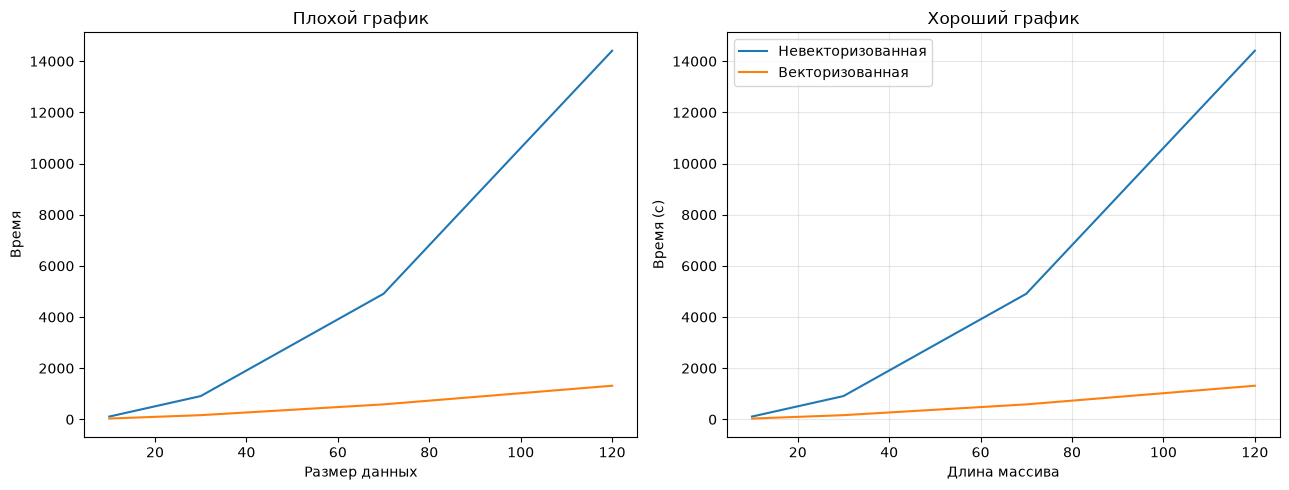

In [2]:
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np

import functions
import functions_vectorized

%matplotlib inline


def reload_solution_modules():
    """Reload the two local solution modules after their files change."""
    reload(functions)
    reload(functions_vectorized)


data_size = np.array([10, 30, 70, 120])
time_non_vectorized = data_size**2 + 10
time_vectorized = data_size**1.5

figure, (axis_bad, axis_good) = plt.subplots(1, 2, figsize=(13, 5))

axis_bad.plot(data_size, time_non_vectorized)
axis_bad.plot(data_size, time_vectorized)
axis_bad.set_title("Плохой график")
axis_bad.set_xlabel("Размер данных")
axis_bad.set_ylabel("Время")

axis_good.plot(data_size, time_non_vectorized, label="Невекторизованная")
axis_good.plot(data_size, time_vectorized, label="Векторизованная")
axis_good.set_title("Хороший график")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()


* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ – 3.

In [4]:
import time

def measure_time(func, *args, repeats=2):
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        func(*args)
        end = time.perf_counter()
        times.append((end - start) * 1000)
    return np.mean(times)

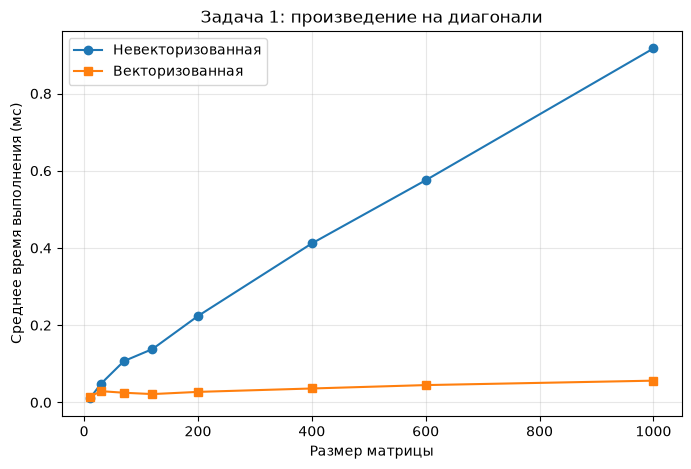

In [48]:
reload_solution_modules()

sizes = [10, 30, 70, 120, 200, 400, 600, 1000]
times_nonvec = []
times_vec = []
mp = 100

for n in sizes:
    t1, t2 = 0, 0
    for k in range(mp):
        X = np.random.randint(-5, 5, size=(n, n))
        
        t1 += measure_time(functions.prod_non_zero_diag, X)
        t2 += measure_time(functions_vectorized.prod_non_zero_diag, X)
        
    times_nonvec.append(t1 / mp)
    times_vec.append(t2 / mp)

plt.figure(figsize=(8,5))
plt.plot(sizes, times_nonvec, 'o-', label='Невекторизованная')
plt.plot(sizes, times_vec, 's-', label='Векторизованная')
plt.xlabel('Размер матрицы')
plt.ylabel('Среднее время выполнения (мс)')
plt.title('Задача 1: произведение на диагонали')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


 
 
* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ – True.
  
  


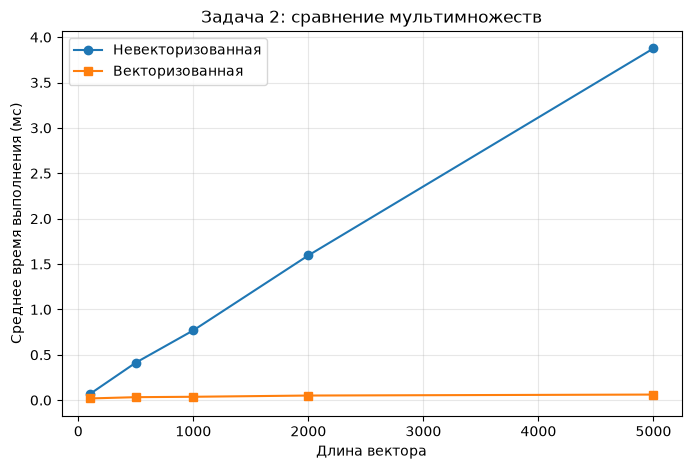

In [51]:
reload_solution_modules()

sizes = [100, 500, 1000, 2000, 5000]
times_nonvec = []
times_vec = []
mp = 100

for n in sizes:
    t1, t2 = 0, 0
    for k in range(mp):
        x = np.random.randint(0, 10, size=n)
        y = np.random.permutation(x)
        
        t1 += measure_time(functions.are_multisets_equal, x, y)
        t2 += measure_time(functions_vectorized.are_multisets_equal, x, y)
    
    times_nonvec.append(t1 / mp)
    times_vec.append(t2 / mp)

plt.figure(figsize=(8,5))
plt.plot(sizes, times_nonvec, 'o-', label='Невекторизованная')
plt.plot(sizes, times_vec, 's-', label='Векторизованная')
plt.xlabel('Длина вектора')
plt.ylabel('Среднее время выполнения (мс)')
plt.title('Задача 2: сравнение мультимножеств')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой.  
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ – 5.

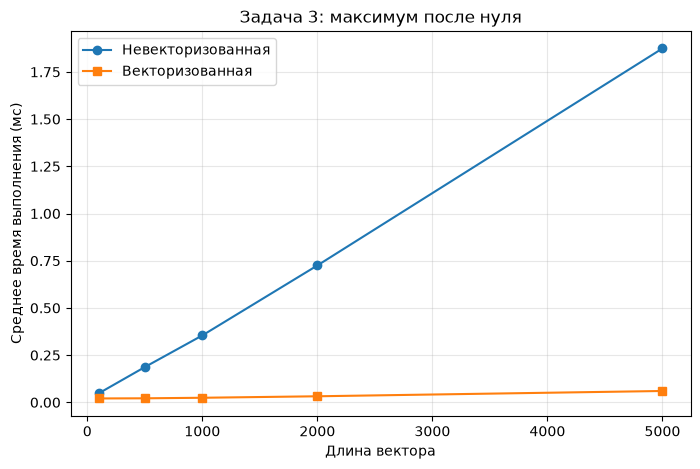

In [50]:
reload_solution_modules()

sizes = [100, 500, 1000, 2000, 5000]
times_nonvec = []
times_vec = []
mp = 100

for n in sizes:
    t1, t2 = 0, 0
    for k in range(mp):
        x = np.random.randint(0, 7, size=n)
        
        t1 += measure_time(functions.max_after_zero, x)
        t2 += measure_time(functions_vectorized.max_after_zero, x)
    
    times_nonvec.append(t1 / 100)
    times_vec.append(t2 / 100)

plt.figure(figsize=(8,5))
plt.plot(sizes, times_nonvec, 'o-', label='Невекторизованная')
plt.plot(sizes, times_vec, 's-', label='Векторизованная')
plt.xlabel('Длина вектора')
plt.ylabel('Среднее время выполнения (мс)')
plt.title('Задача 3: максимум после нуля')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


 
 
* __Задача 4__: Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). В ноутбуке приведите пример работы функции – преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]). Считать реальное изображение можно с помощью `PIL.Image.open` из пакета Pillow: `img = np.asarray(Image.open(path).convert("RGB"))`. Устаревшая функция `scipy.misc.imread` удалена из современных версий SciPy.


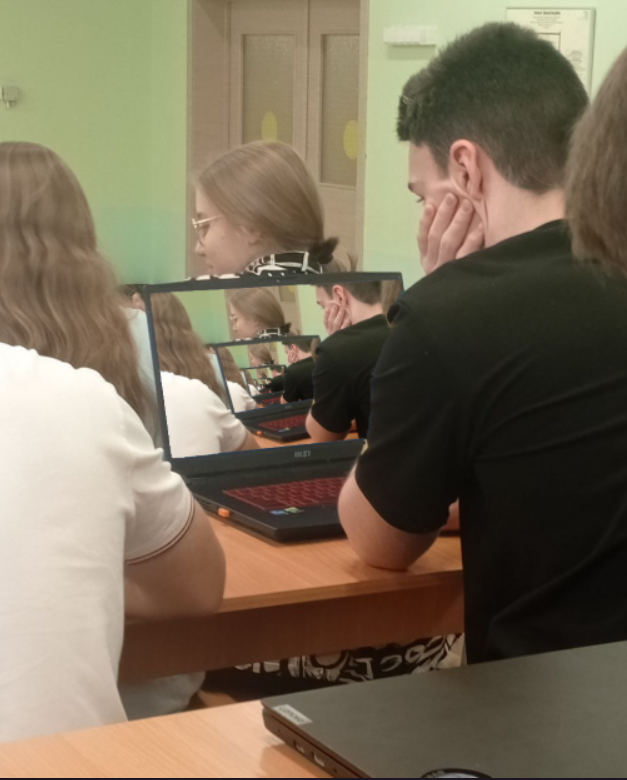

In [51]:
from PIL import Image
img = Image.open('Снимок экрана 2025-11-06 134940.png').convert("RGB")
img

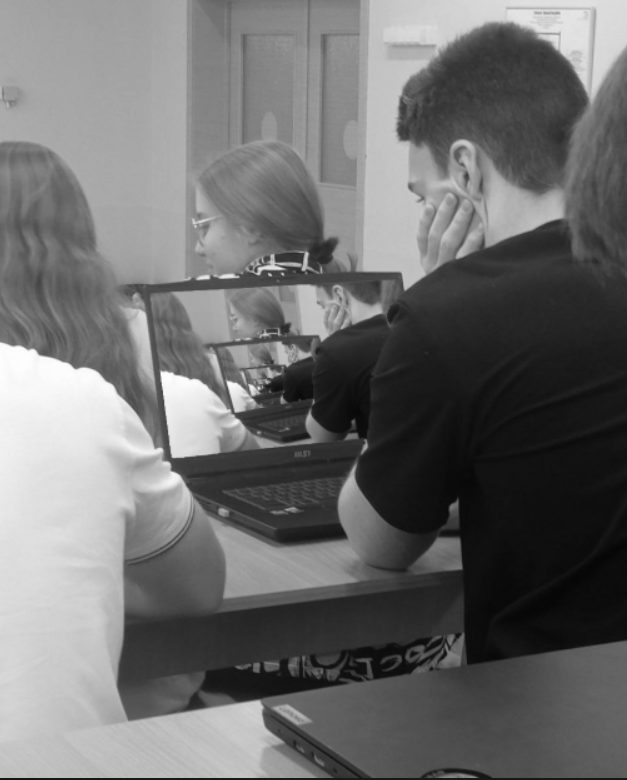

In [52]:
res = functions_vectorized.convert_image(np.array(img), np.array([0.299, 0.587, 0.114]))
a = res.clip(0, 255).astype(np.uint8)
ans = Image.fromarray(a)
ans

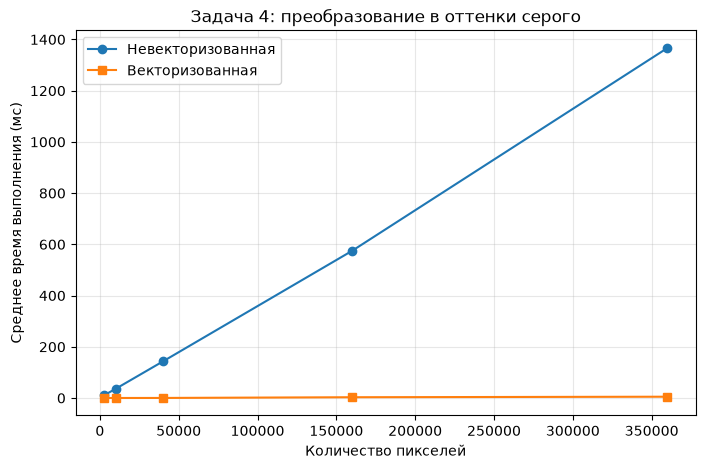

In [5]:
sizes = [(50,50), (100,100), (200,200), (400,400), (600,600)]
times_nonvec = []
times_vec = []

coefs = np.array([0.299, 0.587, 0.114])
mp = 5

for (H, W) in sizes:
    t1, t2 = 0, 0
    for k in range(mp):
        img = np.random.randint(0, 256, size=(H, W, 3), dtype=np.uint8)
        
        t1 += measure_time(functions.convert_image, img, coefs)
        t2 += measure_time(functions_vectorized.convert_image, img, coefs)
    
    times_nonvec.append(t1 / mp)
    times_vec.append(t2 / mp)

ans = [H*W for H, W in sizes]

plt.figure(figsize=(8,5))
plt.plot(ans, times_nonvec, 'o-', label='Невекторизованная')
plt.plot(ans, times_vec, 's-', label='Векторизованная')
plt.xlabel('Количество пикселей')
plt.ylabel('Среднее время выполнения (мс)')
plt.title('Задача 4: преобразование в оттенки серого')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


* __Задача 5__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ – (np.array([2, 3, 5]), np.array([3, 3, 1])).

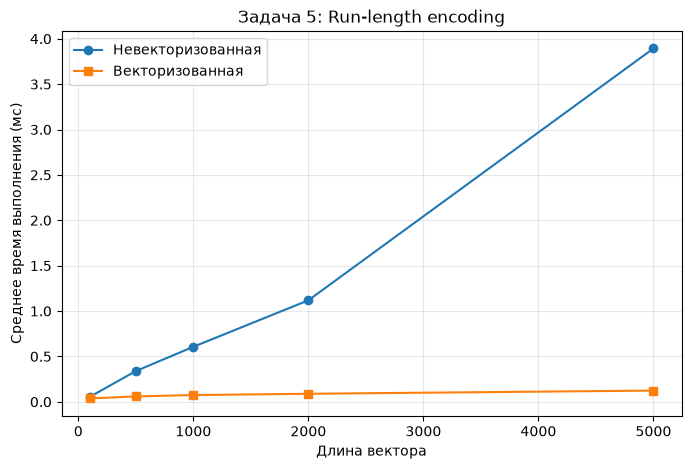

In [61]:
reload_solution_modules()

sizes = [100, 500, 1000, 2000, 5000]
times_nonvec = []
times_vec = []
mp = 20

for n in sizes:
    t1, t2 = 0, 0
    for k in range(mp):
        x = np.random.randint(0, 3, size=n)
        
        t1 += measure_time(functions.run_length_encoding, x)
        t2 += measure_time(functions_vectorized.run_length_encoding, x)
    
    times_nonvec.append(t1 / mp)
    times_vec.append(t2 / mp)

plt.figure(figsize=(8,5))
plt.plot(sizes, times_nonvec, 'o-', label='Невекторизованная')
plt.plot(sizes, times_vec, 's-', label='Векторизованная')
plt.xlabel('Длина вектора')
plt.ylabel('Среднее время выполнения (мс)')
plt.title('Задача 5: Run‑length encoding')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

 
 
* __Задача 6__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Дополнительно сравните с функцией scipy.spatial.distance.cdist по скорости работы (сравнения приведите ниже в ноутбуке).

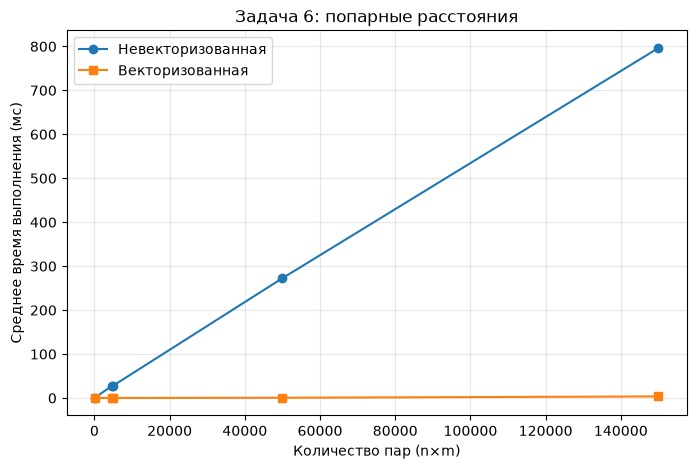

In [65]:
reload_solution_modules()

sizes_n = [10, 20, 100, 500, 500]  
sizes_m = [10, 240, 50, 100, 300]  
d = 5
mp = 5

times_nonvec = []
times_vec = []


for n, m in zip(sizes_n, sizes_m):
    t1, t2 = 0, 0
    for k in range(mp):
        X = np.random.randn(n, d)
        Y = np.random.randn(m, d)
        
        t1 += measure_time(functions.pairwise_distance, X, Y)
        t2 += measure_time(functions_vectorized.pairwise_distance, X, Y)
    
    times_nonvec.append(t1 / mp)
    times_vec.append(t2 / mp)

points = [n*m for n, m in zip(sizes_n, sizes_m)]

plt.figure(figsize=(8,5))
plt.plot(points, times_nonvec, 'o-', label='Невекторизованная')
plt.plot(points, times_vec, 's-', label='Векторизованная')
plt.xlabel('Количество пар (n×m)')
plt.ylabel('Среднее время выполнения (мс)')
plt.title('Задача 6: попарные расстояния')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Туториал по Markdown

__(1 балл)__

Напишите краткий (а в данной домашке ещё и почти бесмысленный) отчёт с использованием 4-5 различных вариантов разметки/выделения текста.

# Отчёт по домашнему заданию 😝

## Выводы по производительности

В ходе экспериментов были построены графики времени выполнения для **невекторизованной** и **векторизованной** реализаций каждой задачи.

*   Для задач с **линейной** сложностью ___(№2, №3, №5)___ векторизация даёт ускорение в несколько раз, но разница становится заметной только на больших объёмах данных.
*   Для задач с **квадратичной** сложностью _(№6)_ и **матричных** операций _(№1, №4)_ векторизованные версии демонстрируют значительный прирост производительности, особенно при росте размеров.

## Используемые технологии

- `numpy` – для работы с массивами и векторизованных вычислений.
- `matplotlib` – для визуализации результатов.
- `time.perf_counter` – для точного измерения времени.